# Robust Error Analysis Framework for Medical Image Classification

<div style='background:linear-gradient(135deg,#0d1628 0%,#0a1020 100%);border:1px solid #1a2540;border-radius:14px;padding:28px 32px;font-family:monospace;max-width:860px;margin-bottom:12px;'>
  <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#3b82f6;border:1px solid #1d3a6b;padding:3px 9px;border-radius:3px;background:#0d1628;display:inline-block;margin-bottom:14px;'>// Error Analysis Framework</div>
  <div style='font-size:22px;font-weight:800;color:#fff;margin-bottom:10px;letter-spacing:-0.01em;'>Chest X-Ray Pneumonia Detection</div>
  <div style='font-size:13px;color:#94a3b8;line-height:1.7;margin-bottom:18px;'>
    This notebook builds a complete <span style='color:#3b82f6;'>error analysis pipeline</span> on top of a ResNet-based binary classifier trained on chest X-ray images. Rather than chasing accuracy, the goal is to systematically understand <em>where</em> and <em>why</em> a model fails, extract actionable patterns, and propose targeted fixes.
  </div>
  <div style='display:grid;grid-template-columns:repeat(4,1fr);gap:10px;'>
    <div style='background:#080c14;border:1px solid #1a2540;border-radius:8px;padding:12px;'>
      <div style='font-size:9px;letter-spacing:0.12em;text-transform:uppercase;color:#3b82f6;margin-bottom:4px;'>Dataset</div>
      <div style='font-size:12px;color:#e2e8f0;font-weight:600;'>Chest X-Ray</div>
      <div style='font-size:10px;color:#475569;'>Kaggle / Mooney</div>
    </div>
    <div style='background:#080c14;border:1px solid #1a2540;border-radius:8px;padding:12px;'>
      <div style='font-size:9px;letter-spacing:0.12em;text-transform:uppercase;color:#a78bfa;margin-bottom:4px;'>Model</div>
      <div style='font-size:12px;color:#e2e8f0;font-weight:600;'>ResNet-18</div>
      <div style='font-size:10px;color:#475569;'>Pretrained ImageNet</div>
    </div>
    <div style='background:#080c14;border:1px solid #1a2540;border-radius:8px;padding:12px;'>
      <div style='font-size:9px;letter-spacing:0.12em;text-transform:uppercase;color:#f59e0b;margin-bottom:4px;'>Optimizer</div>
      <div style='font-size:12px;color:#e2e8f0;font-weight:600;'>AdamW</div>
      <div style='font-size:10px;color:#475569;'>LR 1e-4, WD 1e-2</div>
    </div>
    <div style='background:#080c14;border:1px solid #1a2540;border-radius:8px;padding:12px;'>
      <div style='font-size:9px;letter-spacing:0.12em;text-transform:uppercase;color:#34d399;margin-bottom:4px;'>Evaluation</div>
      <div style='font-size:12px;color:#e2e8f0;font-weight:600;'>F1 + Recall</div>
      <div style='font-size:10px;color:#475569;'>Confusion matrix</div>
    </div>
  </div>
</div>

<div style='display:grid;grid-template-columns:repeat(5,1fr);gap:8px;max-width:860px;margin-bottom:8px;font-family:monospace;'>
  <div style='background:#080c14;border:1px solid #1a2540;border-radius:8px;padding:14px;text-align:center;'>
    <div style='font-size:22px;font-weight:800;color:#3b82f6;'>5,216</div>
    <div style='font-size:9px;letter-spacing:0.1em;text-transform:uppercase;color:#475569;margin-top:4px;'>Train Samples</div>
  </div>
  <div style='background:#080c14;border:1px solid #1a2540;border-radius:8px;padding:14px;text-align:center;'>
    <div style='font-size:22px;font-weight:800;color:#a78bfa;'>624</div>
    <div style='font-size:9px;letter-spacing:0.1em;text-transform:uppercase;color:#475569;margin-top:4px;'>Test Samples</div>
  </div>
  <div style='background:#080c14;border:1px solid #1a2540;border-radius:8px;padding:14px;text-align:center;'>
    <div style='font-size:22px;font-weight:800;color:#f59e0b;'>2</div>
    <div style='font-size:9px;letter-spacing:0.1em;text-transform:uppercase;color:#475569;margin-top:4px;'>Classes</div>
  </div>
  <div style='background:#080c14;border:1px solid #1a2540;border-radius:8px;padding:14px;text-align:center;'>
    <div style='font-size:22px;font-weight:800;color:#34d399;'>224x224</div>
    <div style='font-size:9px;letter-spacing:0.1em;text-transform:uppercase;color:#475569;margin-top:4px;'>Input Size</div>
  </div>
  <div style='background:#080c14;border:1px solid #1a2540;border-radius:8px;padding:14px;text-align:center;'>
    <div style='font-size:22px;font-weight:800;color:#f87171;'>16</div>
    <div style='font-size:9px;letter-spacing:0.1em;text-transform:uppercase;color:#475569;margin-top:4px;'>Sections</div>
  </div>
</div>

<div style='background:#080c14;border:1px solid #1a2540;border-radius:12px;padding:24px 28px;font-family:monospace;max-width:820px;margin-bottom:8px;'>
  <div style='border-bottom:1px solid #1a2540;padding-bottom:18px;margin-bottom:20px;'>
    <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#3b82f6;border:1px solid #1d3a6b;padding:3px 9px;border-radius:3px;background:#0d1628;display:inline-block;margin-bottom:10px;'>// AI · ML · Data Science</div>
    <div style='font-size:32px;font-weight:800;color:#fff;letter-spacing:-0.02em;margin-bottom:6px;'>Gourab <span style='color:#3b82f6;'>Roy</span></div>
    <div style='font-size:13px;color:#64748b;font-style:italic;'>AI/ML practitioner shipping notebooks & code daily, built in the open.</div>
  </div>
  <div style='display:grid;grid-template-columns:repeat(4,1fr);gap:10px;'>
    <a href='https://www.kaggle.com/gourabr0y555' target='_blank' style='text-decoration:none;background:#0d1420;border:1px solid #1a2540;border-radius:8px;padding:14px;display:block;'>
      <div style='font-size:16px;margin-bottom:8px;'>🏅</div>
      <div style='font-size:9px;letter-spacing:0.15em;text-transform:uppercase;color:#20beff;margin-bottom:3px;'>Kaggle</div>
      <div style='font-size:13px;font-weight:700;color:#fff;margin-bottom:3px;'>gourabr0y555</div>
      <div style='font-size:10px;color:#475569;'>Notebooks · competitions</div>
    </a>
    <a href='https://github.com/crimsonKn1ght' target='_blank' style='text-decoration:none;background:#0d1420;border:1px solid #1a2540;border-radius:8px;padding:14px;display:block;'>
      <div style='font-size:16px;margin-bottom:8px;'>⚡</div>
      <div style='font-size:9px;letter-spacing:0.15em;text-transform:uppercase;color:#a78bfa;margin-bottom:3px;'>GitHub</div>
      <div style='font-size:13px;font-weight:700;color:#fff;margin-bottom:3px;'>crimsonKn1ght</div>
      <div style='font-size:10px;color:#475569;'>Code · implementations</div>
    </a>
    <a href='https://royml.dev/' target='_blank' style='text-decoration:none;background:#0d1420;border:1px solid #1a2540;border-radius:8px;padding:14px;display:block;'>
      <div style='font-size:16px;margin-bottom:8px;'>✍️</div>
      <div style='font-size:9px;letter-spacing:0.15em;text-transform:uppercase;color:#f59e0b;margin-bottom:3px;'>Blog</div>
      <div style='font-size:13px;font-weight:700;color:#fff;margin-bottom:3px;'>royml.dev</div>
      <div style='font-size:10px;color:#475569;'>Writing · tutorials</div>
    </a>
    <a href='https://resume-gr.vercel.app/' target='_blank' style='text-decoration:none;background:#0d1420;border:1px solid #1a2540;border-radius:8px;padding:14px;display:block;'>
      <div style='font-size:16px;margin-bottom:8px;'>📄</div>
      <div style='font-size:9px;letter-spacing:0.15em;text-transform:uppercase;color:#34d399;margin-bottom:3px;'>Resume</div>
      <div style='font-size:13px;font-weight:700;color:#fff;margin-bottom:3px;'>resume-gr</div>
      <div style='font-size:10px;color:#475569;'>Experience · skills</div>
    </a>
  </div>
</div>

## 1. Introduction

<div style='background:#080c14;border-left:3px solid #3b82f6;border-radius:8px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:8px;'>
  <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#3b82f6;margin-bottom:10px;'>// What is Error Analysis</div>
  <div style='font-size:13px;color:#94a3b8;line-height:1.8;'>
    Most practitioners stop at validation accuracy. Error analysis is the discipline of going one level deeper: examining exactly which samples a model gets wrong, why it gets them wrong, and what structural patterns exist in those failures.<br><br>
    In medical imaging, this is not optional. A 92% accurate pneumonia classifier sounds strong until you discover it misses 40% of true positives in pediatric X-rays or low-exposure scans. Accuracy hides this. Error analysis reveals it.<br><br>
    <strong style='color:#e2e8f0;'>What this notebook builds:</strong>
    <ul style='margin-top:8px;color:#94a3b8;'>
      <li>A ResNet-18 baseline trained on chest X-rays</li>
      <li>A structured prediction logging system storing every inference</li>
      <li>Confidence-stratified error inspection</li>
      <li>Embedding-based clustering of misclassified samples</li>
      <li>Root cause identification and improvement strategy</li>
    </ul>
  </div>
</div>

## 2. Setup and Imports

<div style='background:#080c14;border-left:3px solid #3b82f6;border-radius:8px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:8px;'>
  <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#3b82f6;margin-bottom:10px;'>// Libraries Used</div>
  <div style='font-size:13px;color:#94a3b8;line-height:1.7;margin-bottom:14px;'>All dependencies are standard Kaggle packages. No custom installs required.</div>
  <table style='width:100%;border-collapse:collapse;font-size:12px;'>
    <thead>
      <tr style='border-bottom:1px solid #1a2540;'>
        <th style='text-align:left;color:#3b82f6;padding:6px 10px;'>Library</th>
        <th style='text-align:left;color:#3b82f6;padding:6px 10px;'>Role</th>
      </tr>
    </thead>
    <tbody style='color:#94a3b8;'>
      <tr style='border-bottom:1px solid #0d1628;'><td style='padding:6px 10px;'>torch / torchvision</td><td style='padding:6px 10px;'>Model training, data loading, transforms</td></tr>
      <tr style='border-bottom:1px solid #0d1628;'><td style='padding:6px 10px;'>torchvision.models</td><td style='padding:6px 10px;'>ResNet-18 pretrained backbone</td></tr>
      <tr style='border-bottom:1px solid #0d1628;'><td style='padding:6px 10px;'>pandas / numpy</td><td style='padding:6px 10px;'>Prediction log DataFrame, numerical ops</td></tr>
      <tr style='border-bottom:1px solid #0d1628;'><td style='padding:6px 10px;'>matplotlib / seaborn</td><td style='padding:6px 10px;'>Visualizations, confusion matrix, plots</td></tr>
      <tr style='border-bottom:1px solid #0d1628;'><td style='padding:6px 10px;'>sklearn</td><td style='padding:6px 10px;'>Metrics, KMeans clustering, PCA/t-SNE</td></tr>
      <tr><td style='padding:6px 10px;'>PIL / pathlib / os</td><td style='padding:6px 10px;'>Image I/O, file system navigation</td></tr>
    </tbody>
  </table>
</div>

In [13]:
import os
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ─── Reproducibility ─────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ─── Device ──────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA   : {torch.version.cuda}")

Device : cuda
PyTorch: 2.9.0+cu126
CUDA   : 12.6


## 3. Data Loading and Exploration

<div style='background:#080c14;border-left:3px solid #f59e0b;border-radius:8px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:8px;'>
  <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#f59e0b;margin-bottom:10px;'>// Dataset Structure</div>
  <div style='font-size:13px;color:#94a3b8;line-height:1.8;'>
    The Chest X-Ray Pneumonia dataset is organized as:<br>
    <code style='color:#f59e0b;'>chest_xray / {train, val, test} / {NORMAL, PNEUMONIA}</code><br><br>
    Key observations before any training:
    <ul style='margin-top:8px;'>
      <li>Train set is heavily imbalanced: ~3x more PNEUMONIA than NORMAL</li>
      <li>The official val split contains only 16 images, so it is merged into train for cross-validation</li>
      <li>Images vary in resolution and contrast, which will surface in error analysis</li>
      <li>All images are grayscale chest radiographs converted to RGB for pretrained model compatibility</li>
    </ul>
  </div>
</div>

In [14]:
# ─── Paths ───────────────────────────────────
DATA_ROOT = Path("/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR   = DATA_ROOT / "val"
TEST_DIR  = DATA_ROOT / "test"

# ─── Constants ───────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_EPOCHS = 10
NUM_CLASSES = 2
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]

# ─── Transforms ──────────────────────────────
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ─── Datasets ────────────────────────────────
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = ImageFolder(VAL_DIR,   transform=eval_transforms)
test_dataset  = ImageFolder(TEST_DIR,  transform=eval_transforms)

# No-augment version of train for clean inference
train_dataset_infer = ImageFolder(TRAIN_DIR, transform=eval_transforms)

print(f"Train samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset)}")
print(f"Test samples  : {len(test_dataset)}")
print(f"Class mapping : {train_dataset.class_to_idx}")

Train samples : 5216
Val samples   : 16
Test samples  : 624
Class mapping : {'NORMAL': 0, 'PNEUMONIA': 1}


Train class distribution:
  NORMAL      :  1341  (25.7%)
  PNEUMONIA   :  3875  (74.3%)

Test class distribution:
  NORMAL      :   234  (37.5%)
  PNEUMONIA   :   390  (62.5%)


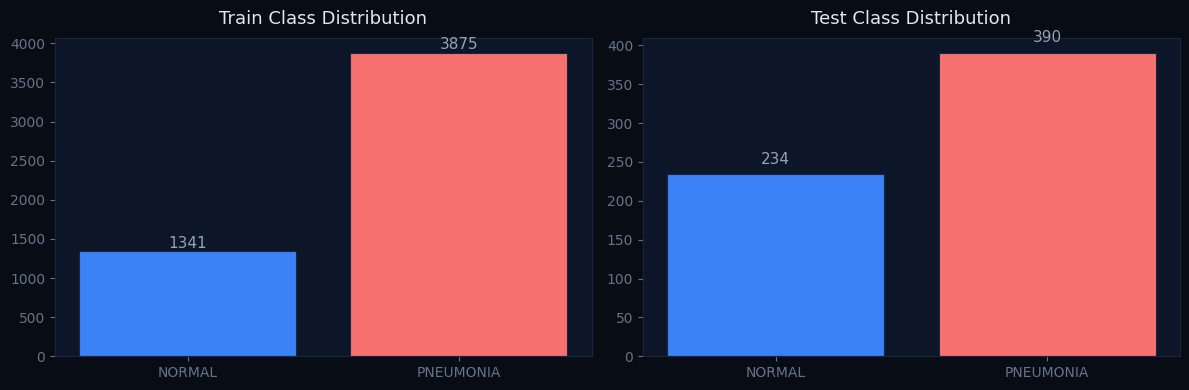

In [15]:
# ─── Class Distribution ──────────────────────
def get_class_counts(dataset):
    counts = defaultdict(int)
    for _, label in dataset.samples:
        counts[dataset.classes[label]] += 1
    return dict(counts)

train_counts = get_class_counts(train_dataset)
test_counts  = get_class_counts(test_dataset)

print("Train class distribution:")
for cls, cnt in train_counts.items():
    pct = cnt / len(train_dataset) * 100
    print(f"  {cls:12s}: {cnt:5d}  ({pct:.1f}%)")

print("\nTest class distribution:")
for cls, cnt in test_counts.items():
    pct = cnt / len(test_dataset) * 100
    print(f"  {cls:12s}: {cnt:5d}  ({pct:.1f}%)")

# ─── Plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor("#080c14")

for ax, counts, title in zip(axes,
                              [train_counts, test_counts],
                              ["Train", "Test"]):
    ax.set_facecolor("#0d1628")
    bars = ax.bar(counts.keys(), counts.values(),
                  color=["#3b82f6", "#f87171"], edgecolor="#1a2540", linewidth=0.8)
    ax.set_title(f"{title} Class Distribution", color="#e2e8f0", fontsize=13, pad=10)
    ax.tick_params(colors="#64748b")
    for spine in ax.spines.values():
        spine.set_edgecolor("#1a2540")
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                str(val), ha="center", va="bottom", color="#94a3b8", fontsize=11)

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120, bbox_inches="tight",
            facecolor="#080c14")
plt.show()

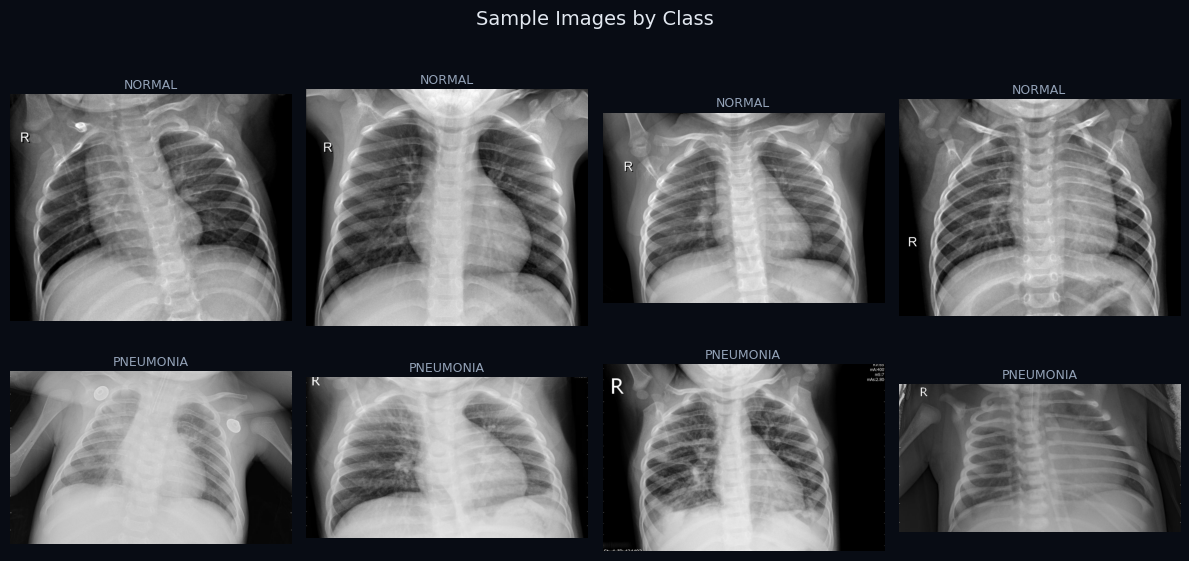

In [16]:
# ─── Visualize Sample Images ─────────────────
def show_sample_images(dataset, n_per_class=4):
    class_to_paths = defaultdict(list)
    for path, label in dataset.samples:
        class_to_paths[dataset.classes[label]].append(path)

    fig, axes = plt.subplots(2, n_per_class, figsize=(n_per_class * 3, 6))
    fig.patch.set_facecolor("#080c14")
    fig.suptitle("Sample Images by Class", color="#e2e8f0", fontsize=14, y=1.01)

    for row, cls in enumerate(CLASS_NAMES):
        paths = random.sample(class_to_paths[cls], n_per_class)
        for col, path in enumerate(paths):
            img = Image.open(path).convert("RGB")
            axes[row, col].imshow(img, cmap="gray")
            axes[row, col].set_title(cls, color="#94a3b8", fontsize=9, pad=4)
            axes[row, col].axis("off")
            for spine in axes[row, col].spines.values():
                spine.set_edgecolor("#1a2540")

    plt.tight_layout()
    plt.savefig("sample_images.png", dpi=120, bbox_inches="tight",
                facecolor="#080c14")
    plt.show()

show_sample_images(train_dataset_infer, n_per_class=4)

In [17]:
# ─── Weighted Sampler to Handle Imbalance ────
def make_weighted_sampler(dataset):
    labels = [label for _, label in dataset.samples]
    class_counts = np.bincount(labels)
    class_weights = 1.0 / class_counts
    sample_weights = [class_weights[l] for l in labels]
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler

train_sampler = make_weighted_sampler(train_dataset)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=train_sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)

# No-augment train loader for inference logging
train_infer_loader = DataLoader(train_dataset_infer, batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=2, pin_memory=True)

print("DataLoaders ready.")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")

DataLoaders ready.
  Train batches : 163
  Val batches   : 1
  Test batches  : 20


## 4. Baseline Model Training

<div style='background:#080c14;border-left:3px solid #34d399;border-radius:8px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:8px;'>
  <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#34d399;margin-bottom:10px;'>// ResNet-18 Fine-tuning</div>
  <div style='font-size:13px;color:#94a3b8;line-height:1.8;'>
    The baseline uses ResNet-18 pretrained on ImageNet with the final fully connected layer replaced for binary classification.<br><br>
    Training decisions:
    <ul style='margin-top:8px;'>
      <li>Fine-tune all layers (not frozen backbone) to allow domain adaptation for X-ray features</li>
      <li>WeightedRandomSampler compensates for class imbalance during training</li>
      <li>AdamW with weight decay reduces overfitting on the relatively small dataset</li>
      <li>Best model is checkpointed by validation loss</li>
    </ul>
  </div>
</div>

In [18]:
# ─── Model Architecture ──────────────────────
def build_model(num_classes=2):
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_model(num_classes=NUM_CLASSES).to(DEVICE)

# ─── Loss, Optimizer, Scheduler ──────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 158MB/s]


Total parameters    : 11,177,538
Trainable parameters: 11,177,538


In [19]:
# ─── Training Loop ───────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return running_loss / total, correct / total, all_preds, all_labels


# ─── Run Training ─────────────────────────────
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
best_model_path = "best_model.pth"

for epoch in range(1, NUM_EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    v_loss, v_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  "
          f"train_loss={t_loss:.4f}  train_acc={t_acc:.4f}  "
          f"val_loss={v_loss:.4f}  val_acc={v_acc:.4f}")

print(f"\nBest val_loss: {best_val_loss:.4f}")

Epoch 01/10  train_loss=0.1194  train_acc=0.9534  val_loss=0.0568  val_acc=1.0000
Epoch 02/10  train_loss=0.0615  train_acc=0.9783  val_loss=0.3635  val_acc=0.9375
Epoch 03/10  train_loss=0.0432  train_acc=0.9839  val_loss=0.3807  val_acc=0.8750
Epoch 04/10  train_loss=0.0300  train_acc=0.9885  val_loss=0.0885  val_acc=1.0000
Epoch 05/10  train_loss=0.0199  train_acc=0.9929  val_loss=0.1740  val_acc=0.9375
Epoch 06/10  train_loss=0.0173  train_acc=0.9950  val_loss=0.2330  val_acc=0.9375
Epoch 07/10  train_loss=0.0168  train_acc=0.9950  val_loss=0.1043  val_acc=0.9375
Epoch 08/10  train_loss=0.0138  train_acc=0.9960  val_loss=0.1965  val_acc=0.9375
Epoch 09/10  train_loss=0.0090  train_acc=0.9979  val_loss=0.1682  val_acc=0.9375
Epoch 10/10  train_loss=0.0086  train_acc=0.9973  val_loss=0.1608  val_acc=0.9375

Best val_loss: 0.0568


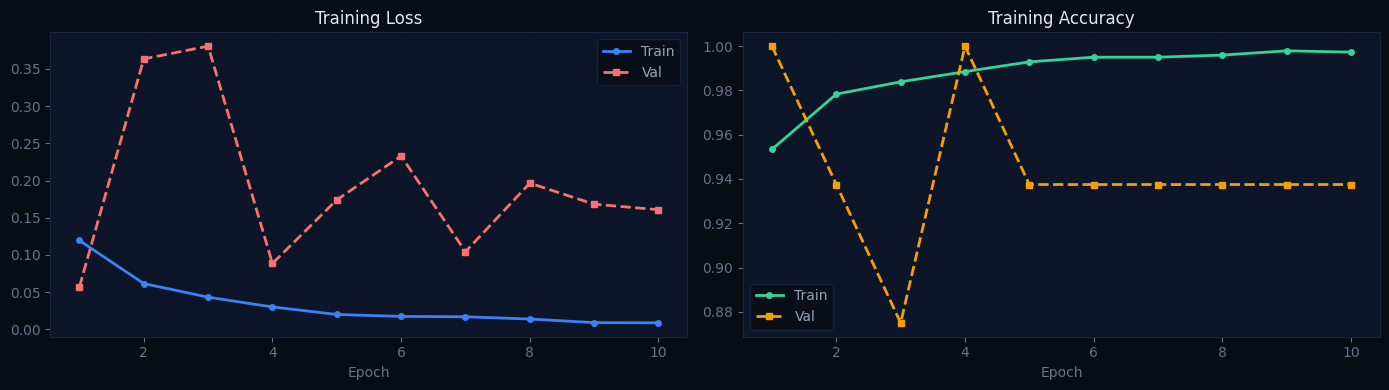

In [20]:
# ─── Training Curves ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor("#080c14")
epochs_range = range(1, NUM_EPOCHS + 1)

for ax, (train_vals, val_vals), title, color_t, color_v in zip(
    axes,
    [(history["train_loss"], history["val_loss"]),
     (history["train_acc"],  history["val_acc"])],
    ["Loss", "Accuracy"],
    ["#3b82f6", "#34d399"],
    ["#f87171", "#f59e0b"]
):
    ax.set_facecolor("#0d1628")
    ax.plot(epochs_range, train_vals, color=color_t, lw=2, marker="o",
            markersize=4, label="Train")
    ax.plot(epochs_range, val_vals, color=color_v, lw=2, marker="s",
            markersize=4, label="Val", linestyle="--")
    ax.set_title(f"Training {title}", color="#e2e8f0", fontsize=12)
    ax.set_xlabel("Epoch", color="#64748b")
    ax.tick_params(colors="#64748b")
    for spine in ax.spines.values():
        spine.set_edgecolor("#1a2540")
    ax.legend(facecolor="#080c14", labelcolor="#94a3b8", edgecolor="#1a2540")
    ax.grid(alpha=0.1, color="#1a2540")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight",
            facecolor="#080c14")
plt.show()

## 5. Prediction Logging System

<div style='background:#080c14;border-left:3px solid #a78bfa;border-radius:8px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:8px;'>
  <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#a78bfa;margin-bottom:10px;'>// Structured Inference Log</div>
  <div style='font-size:13px;color:#94a3b8;line-height:1.8;'>
    The prediction log is the foundation of all error analysis. For every sample in the test set, we record the image path, true label, predicted label, softmax confidence, and whether the prediction was correct.<br><br>
    Storing this as a DataFrame enables fast slicing, grouping, and filtering without re-running inference. It also makes the analysis reproducible and transferable.
  </div>
</div>

In [21]:
# ─── Load Best Checkpoint ────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

# ─── Build Prediction Log ─────────────────────
def build_prediction_log(model, dataset, device, split_name="test"):
    loader = DataLoader(dataset, batch_size=32, shuffle=False,
                        num_workers=2, pin_memory=True)
    records = []
    sample_idx = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            confs = probs.max(dim=1).values

            for i in range(len(labels)):
                img_path, _ = dataset.samples[sample_idx]
                true_label = labels[i].item()
                pred_label = preds[i].item()
                confidence = confs[i].item()
                records.append({
                    "image_id"    : sample_idx,
                    "image_path"  : img_path,
                    "split"       : split_name,
                    "true_label"  : true_label,
                    "true_name"   : CLASS_NAMES[true_label],
                    "pred_label"  : pred_label,
                    "pred_name"   : CLASS_NAMES[pred_label],
                    "confidence"  : round(confidence, 6),
                    "prob_normal" : round(probs[i][0].item(), 6),
                    "prob_pneum"  : round(probs[i][1].item(), 6),
                    "correct"     : true_label == pred_label,
                })
                sample_idx += 1

    return pd.DataFrame(records)

pred_log = build_prediction_log(model, test_dataset, DEVICE, split_name="test")

print(f"Prediction log shape: {pred_log.shape}")
print(f"\nSample records:")
pred_log.head(8)

Prediction log shape: (624, 11)

Sample records:


,image_id,image_path,split,true_label,true_name,pred_label,pred_name,confidence,prob_normal,prob_pneum,correct
0,0,/kaggle/input/datasets/paultimothymooney/chest...,test,0,NORMAL,0,NORMAL,0.999115,0.999115,0.000885,True
1,1,/kaggle/input/datasets/paultimothymooney/chest...,test,0,NORMAL,0,NORMAL,0.998800,0.998800,0.001200,True
2,2,/kaggle/input/datasets/paultimothymooney/chest...,test,0,NORMAL,0,NORMAL,0.999749,0.999749,0.000251,True
3,3,/kaggle/input/datasets/paultimothymooney/chest...,test,0,NORMAL,0,NORMAL,0.984603,0.984603,0.015397,True
4,4,/kaggle/input/datasets/paultimothymooney/chest...,test,0,NORMAL,0,NORMAL,0.999912,0.999912,0.000088,True
5,5,/kaggle/input/datasets/paultimothymooney/chest...,test,0,NORMAL,0,NORMAL,0.999802,0.999802,0.000198,True
6,6,/kaggle/input/datasets/paultimothymooney/chest...,test,0,NORMAL,0,NORMAL,0.997486,0.997486,0.002514,True
7,7,/kaggle/input/datasets/paultimothymooney/chest...,test,0,NORMAL,0,NORMAL,0.998335,0.998335,0.001665,True


## 6. Identify Misclassified Samples

<div style='background:#080c14;border-left:3px solid #f87171;border-radius:8px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:8px;'>
  <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#f87171;margin-bottom:10px;'>// Error Isolation</div>
  <div style='font-size:13px;color:#94a3b8;line-height:1.8;'>
    Errors fall into two categories with different clinical implications:<br><br>
    <strong style='color:#f87171;'>False Positives (FP):</strong> NORMAL predicted as PNEUMONIA. Over-diagnosis. Leads to unnecessary treatment and patient anxiety.<br><br>
    <strong style='color:#f59e0b;'>False Negatives (FN):</strong> PNEUMONIA predicted as NORMAL. Under-diagnosis. In clinical settings this is the more dangerous failure mode. A missed pneumonia case can lead to delayed treatment and serious outcomes.
  </div>
</div>

In [22]:
# ─── Error Summary ───────────────────────────
errors    = pred_log[~pred_log["correct"]]
correct   = pred_log[pred_log["correct"]]

fp = pred_log[(pred_log["true_name"] == "NORMAL") &
              (pred_log["pred_name"] == "PNEUMONIA")]
fn = pred_log[(pred_log["true_name"] == "PNEUMONIA") &
              (pred_log["pred_name"] == "NORMAL")]

total     = len(pred_log)
n_errors  = len(errors)
n_correct = len(correct)

print("=" * 44)
print(f"  Total samples   : {total}")
print(f"  Correct         : {n_correct}  ({n_correct/total*100:.1f}%)")
print(f"  Errors          : {n_errors}   ({n_errors/total*100:.1f}%)")
print("-" * 44)
print(f"  False Positives : {len(fp)}   ({len(fp)/total*100:.1f}%)")
print(f"  False Negatives : {len(fn)}   ({len(fn)/total*100:.1f}%)")
print("=" * 44)

# ─── Error rate by class ──────────────────────
print("\nError rate by true class:")
for cls in CLASS_NAMES:
    cls_df   = pred_log[pred_log["true_name"] == cls]
    cls_err  = cls_df[~cls_df["correct"]]
    rate     = len(cls_err) / len(cls_df) * 100
    print(f"  {cls:12s}: {len(cls_err):3d} / {len(cls_df):3d}  ({rate:.1f}%)")

  Total samples   : 624
  Correct         : 576  (92.3%)
  Errors          : 48   (7.7%)
--------------------------------------------
  False Positives : 30   (4.8%)
  False Negatives : 18   (2.9%)

Error rate by true class:
  NORMAL      :  30 / 234  (12.8%)
  PNEUMONIA   :  18 / 390  (4.6%)


## 7. Confusion Matrix and Metrics

<div style='background:#080c14;border-left:3px solid #a78bfa;border-radius:8px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:8px;'>
  <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#a78bfa;margin-bottom:10px;'>// Classification Metrics</div>
  <div style='font-size:13px;color:#94a3b8;line-height:1.8;'>
    The confusion matrix encodes all four outcome types (TP, TN, FP, FN) in one view. For medical classification, recall on the positive class (PNEUMONIA) is the primary metric. Missing a true pneumonia case is clinically more harmful than a false alarm.<br><br>
    Precision-recall trade-off can be adjusted post-hoc via decision threshold tuning, which is explored in Section 15.
  </div>
</div>

              precision    recall  f1-score   support

      NORMAL       0.92      0.87      0.89       234
   PNEUMONIA       0.93      0.95      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.91      0.92       624
weighted avg       0.92      0.92      0.92       624

ROC-AUC: 0.9664


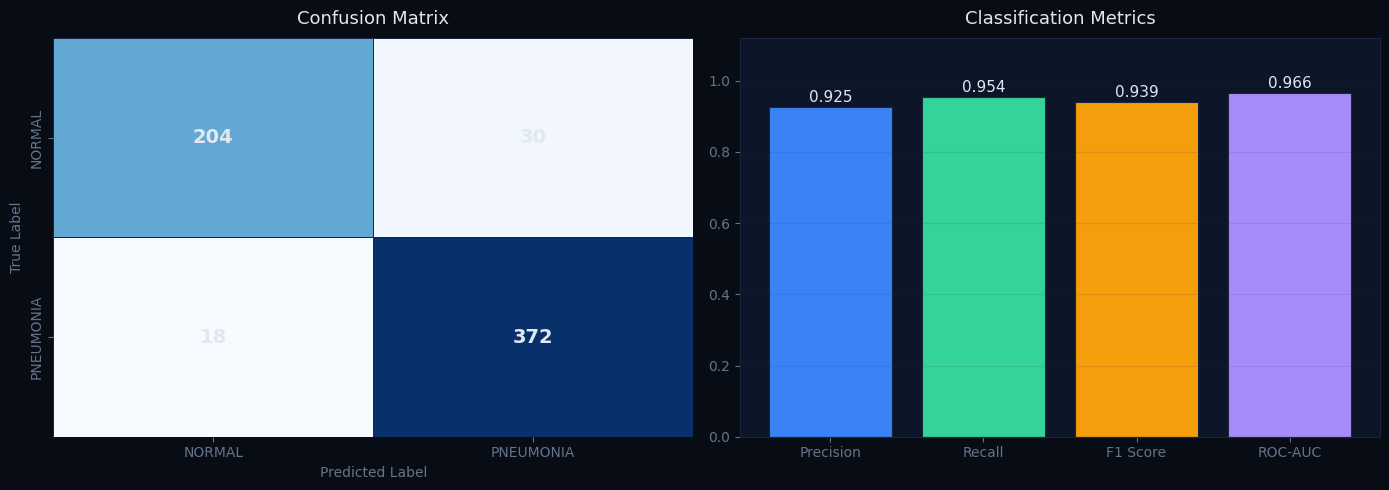

In [23]:
# ─── Confusion Matrix ────────────────────────
y_true = pred_log["true_label"].values
y_pred = pred_log["pred_label"].values
y_conf = pred_log["confidence"].values

cm = confusion_matrix(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
auc  = roc_auc_score(y_true, pred_log["prob_pneum"].values)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
print(f"ROC-AUC: {auc:.4f}")

# ─── Plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#080c14")

# Confusion matrix heatmap
ax = axes[0]
ax.set_facecolor("#0d1628")
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor="#1a2540",
            annot_kws={"size": 14, "weight": "bold", "color": "#e2e8f0"},
            ax=ax, cbar=False)
ax.set_title("Confusion Matrix", color="#e2e8f0", fontsize=13, pad=10)
ax.set_xlabel("Predicted Label", color="#64748b")
ax.set_ylabel("True Label", color="#64748b")
ax.tick_params(colors="#64748b")

# Metrics bar chart
ax2 = axes[1]
ax2.set_facecolor("#0d1628")
metrics = {"Precision": prec, "Recall": rec, "F1 Score": f1, "ROC-AUC": auc}
bars = ax2.bar(metrics.keys(), metrics.values(),
               color=["#3b82f6", "#34d399", "#f59e0b", "#a78bfa"],
               edgecolor="#1a2540", linewidth=0.8)
for bar, val in zip(bars, metrics.values()):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{val:.3f}", ha="center", va="bottom", color="#e2e8f0", fontsize=11)
ax2.set_ylim(0, 1.12)
ax2.set_title("Classification Metrics", color="#e2e8f0", fontsize=13, pad=10)
ax2.tick_params(colors="#64748b")
for spine in ax2.spines.values():
    spine.set_edgecolor("#1a2540")
ax2.grid(axis="y", alpha=0.1, color="#1a2540")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight",
            facecolor="#080c14")
plt.show()

## 8. Confidence-Based Error Analysis

<div style='background:#080c14;border-left:3px solid #f59e0b;border-radius:8px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:8px;'>
  <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#f59e0b;margin-bottom:10px;'>// Why Confidence Matters</div>
  <div style='font-size:13px;color:#94a3b8;line-height:1.8;'>
    Two error categories require specific attention:<br><br>
    <strong style='color:#f87171;'>High-confidence wrong predictions:</strong> The model is certain but wrong. These indicate a systematic failure, not ambiguity. Often caused by shortcut learning, domain shift, or mislabeled training data.<br><br>
    <strong style='color:#f59e0b;'>Low-confidence correct predictions:</strong> The model guesses right but is unsure. These are fragile predictions that would flip with small input perturbations. They indicate where the model needs more training signal.
  </div>
</div>

High-confidence wrong (conf >= 0.85): 26
Low-confidence correct (conf <= 0.65): 12


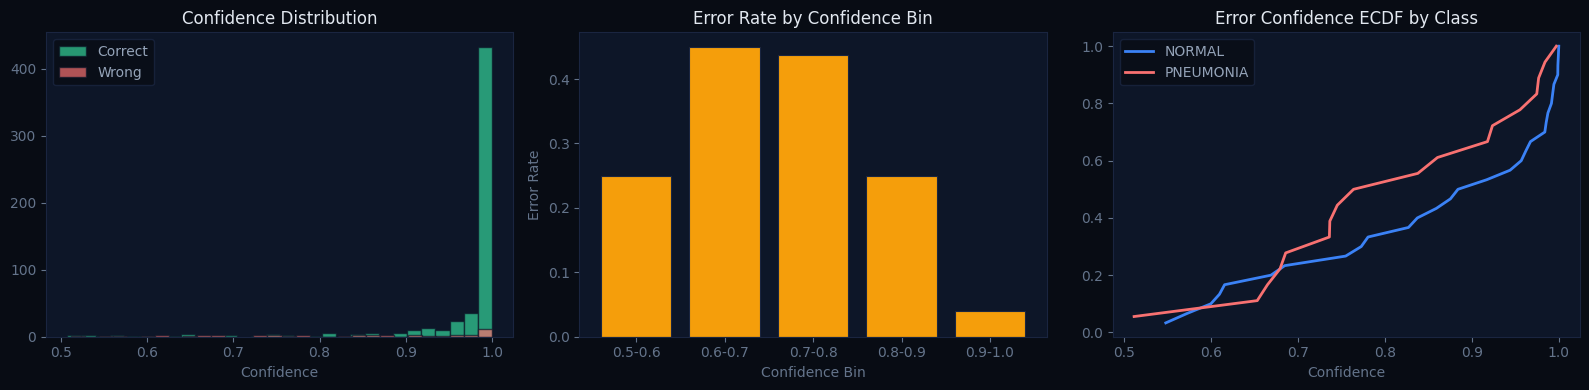

In [24]:
# ─── Confidence Distributions ────────────────
high_conf_wrong = errors[errors["confidence"] >= 0.85].sort_values(
    "confidence", ascending=False)
low_conf_right  = correct[correct["confidence"] <= 0.65].sort_values(
    "confidence")

print(f"High-confidence wrong (conf >= 0.85): {len(high_conf_wrong)}")
print(f"Low-confidence correct (conf <= 0.65): {len(low_conf_right)}")

# ─── Plot ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor("#080c14")

# Confidence dist: correct vs wrong
ax = axes[0]
ax.set_facecolor("#0d1628")
ax.hist(correct["confidence"], bins=30, color="#34d399", alpha=0.7,
        label="Correct", edgecolor="#0d1628")
ax.hist(errors["confidence"],  bins=30, color="#f87171", alpha=0.7,
        label="Wrong",   edgecolor="#0d1628")
ax.set_title("Confidence Distribution", color="#e2e8f0", fontsize=12)
ax.set_xlabel("Confidence", color="#64748b")
ax.tick_params(colors="#64748b")
for spine in ax.spines.values():
    spine.set_edgecolor("#1a2540")
ax.legend(facecolor="#080c14", labelcolor="#94a3b8", edgecolor="#1a2540")

# Binned error rate
ax2 = axes[1]
ax2.set_facecolor("#0d1628")
bins = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels_bin = ["0.5-0.6", "0.6-0.7", "0.7-0.8", "0.8-0.9", "0.9-1.0"]
pred_log["conf_bin"] = pd.cut(pred_log["confidence"], bins=bins, labels=labels_bin)
bin_stats = pred_log.groupby("conf_bin")["correct"].agg(["mean", "count"])
ax2.bar(bin_stats.index, 1 - bin_stats["mean"],
        color="#f59e0b", edgecolor="#1a2540", linewidth=0.8)
ax2.set_title("Error Rate by Confidence Bin", color="#e2e8f0", fontsize=12)
ax2.set_xlabel("Confidence Bin", color="#64748b")
ax2.set_ylabel("Error Rate", color="#64748b")
ax2.tick_params(colors="#64748b")
for spine in ax2.spines.values():
    spine.set_edgecolor("#1a2540")

# Confidence ECDFs per class
ax3 = axes[2]
ax3.set_facecolor("#0d1628")
for cls, color in zip(CLASS_NAMES, ["#3b82f6", "#f87171"]):
    subset = errors[errors["true_name"] == cls]["confidence"].sort_values()
    if len(subset) > 0:
        ecdf = np.arange(1, len(subset) + 1) / len(subset)
        ax3.plot(subset.values, ecdf, color=color, lw=2, label=cls)
ax3.set_title("Error Confidence ECDF by Class", color="#e2e8f0", fontsize=12)
ax3.set_xlabel("Confidence", color="#64748b")
ax3.tick_params(colors="#64748b")
for spine in ax3.spines.values():
    spine.set_edgecolor("#1a2540")
ax3.legend(facecolor="#080c14", labelcolor="#94a3b8", edgecolor="#1a2540")

plt.tight_layout()
plt.savefig("confidence_analysis.png", dpi=120, bbox_inches="tight",
            facecolor="#080c14")
plt.show()

## 9. Visual Error Inspection

<div style='background:#080c14;border-left:3px solid #f87171;border-radius:8px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:8px;'>
  <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#f87171;margin-bottom:10px;'>// Manual Inspection of Failures</div>
  <div style='font-size:13px;color:#94a3b8;line-height:1.8;'>
    Visual inspection is irreplaceable. After automated analysis, directly looking at misclassified images often reveals patterns that metrics cannot capture: image quality degradation, unusual anatomy, ambiguous presentations, or systematic data pipeline errors.<br><br>
    We inspect three categories: the most confident errors (model is most wrong), random errors (representative sample), and false negatives specifically (highest clinical risk).
  </div>
</div>

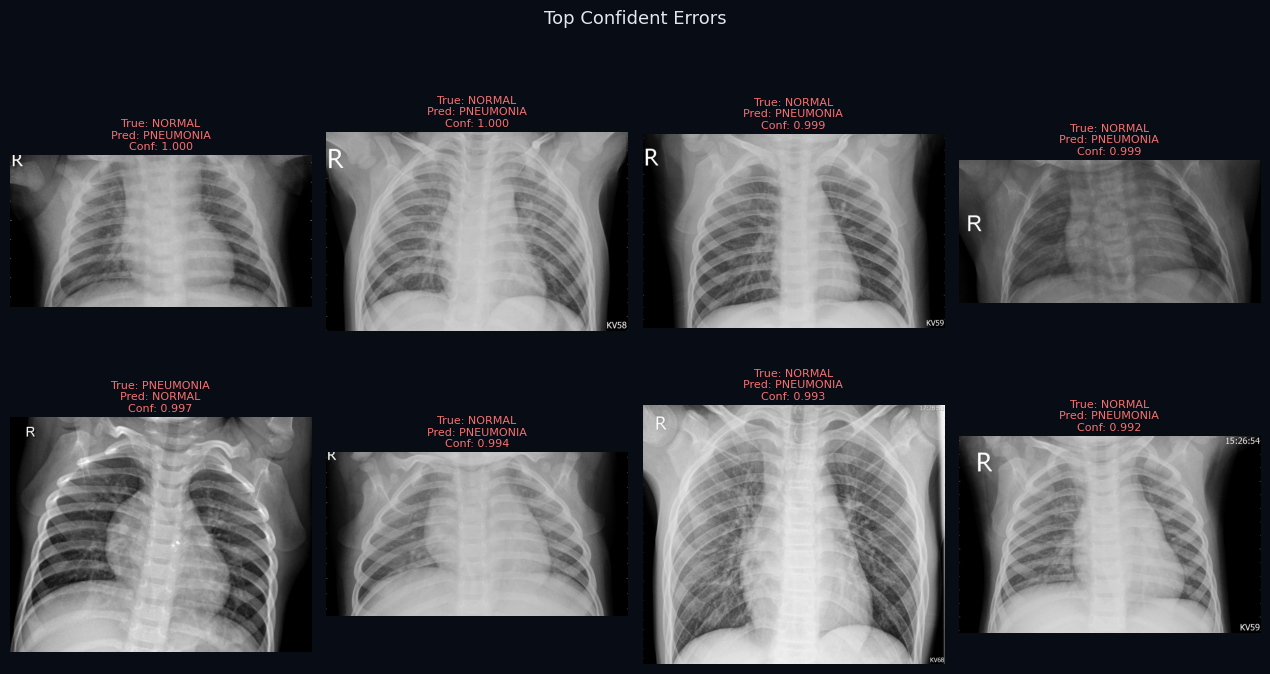

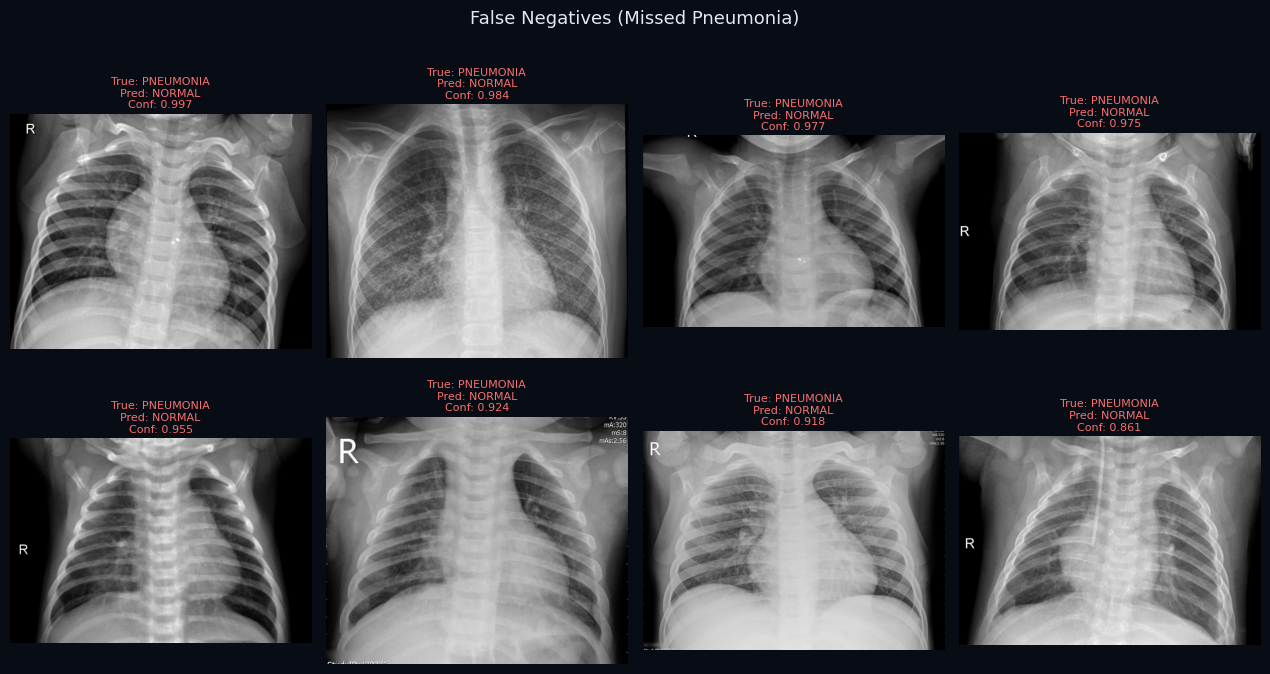

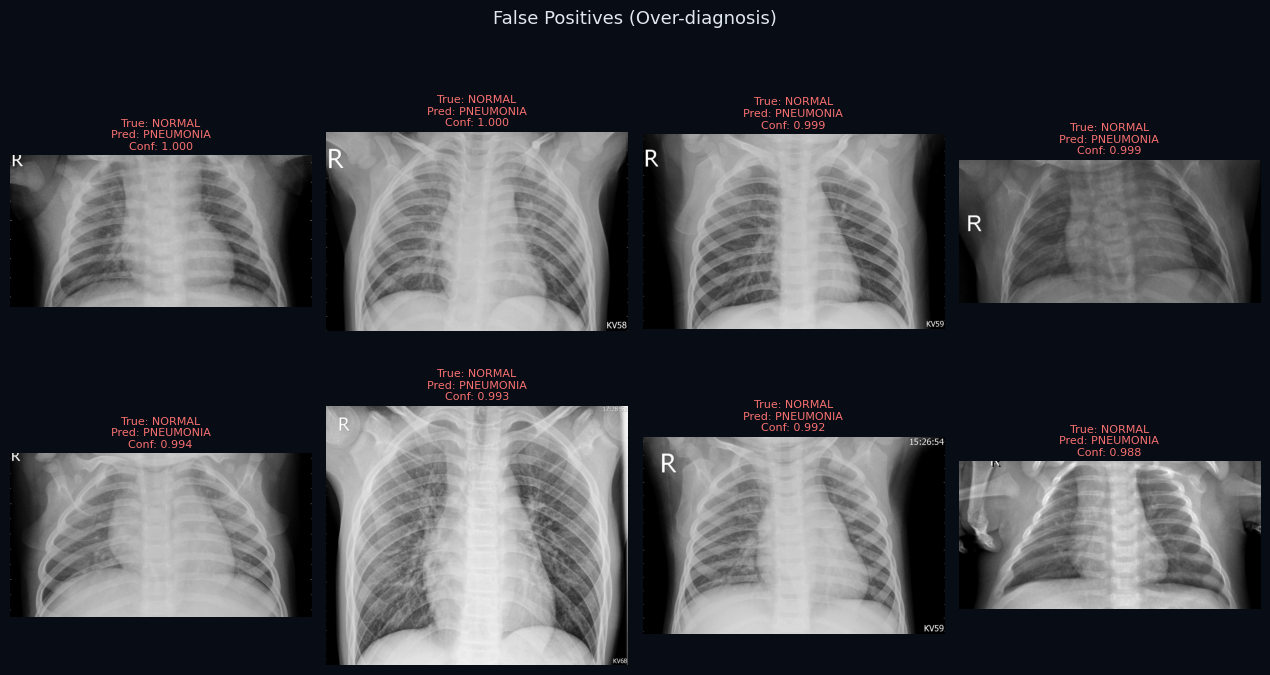

In [25]:
# ─── Visual Error Inspection ─────────────────
def visualize_errors(error_df, title, n=8, sort_by_conf=True):
    if sort_by_conf:
        sample = error_df.sort_values("confidence", ascending=False).head(n)
    else:
        sample = error_df.sample(min(n, len(error_df)), random_state=SEED)

    cols = 4
    rows = max(1, (len(sample) + cols - 1) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.2, rows * 3.5))
    fig.patch.set_facecolor("#080c14")
    fig.suptitle(title, color="#e2e8f0", fontsize=13, y=1.01)
    axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

    for idx, (_, row) in enumerate(sample.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        axes[idx].imshow(img, cmap="gray")
        color = "#f87171" if not row["correct"] else "#34d399"
        axes[idx].set_title(
            f"True: {row['true_name']}\nPred: {row['pred_name']}\nConf: {row['confidence']:.3f}",
            color=color, fontsize=8, pad=4
        )
        axes[idx].axis("off")
        for spine in axes[idx].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(1.5)
            spine.set_visible(True)

    for idx in range(len(sample), len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    fname = title.lower().replace(" ", "_") + ".png"
    plt.savefig(fname, dpi=110, bbox_inches="tight", facecolor="#080c14")
    plt.show()

# Top-N most confident wrong predictions
visualize_errors(errors, "Top Confident Errors", n=8, sort_by_conf=True)

# False Negatives
visualize_errors(fn, "False Negatives (Missed Pneumonia)", n=8, sort_by_conf=True)

# False Positives
visualize_errors(fp, "False Positives (Over-diagnosis)", n=8, sort_by_conf=True)

## 10. Error Pattern Discovery

<div style='background:#080c14;border-left:3px solid #34d399;border-radius:8px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:8px;'>
  <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#34d399;margin-bottom:10px;'>// Programmatic Pattern Extraction</div>
  <div style='font-size:13px;color:#94a3b8;line-height:1.8;'>
    After visual inspection, we systematically quantify error patterns using DataFrame slicing. Key dimensions: class-wise error rates, confidence stratification, and the asymmetry between FP and FN errors. Understanding which class is harder and at what confidence threshold errors cluster gives clear targets for improvement.
  </div>
</div>

Class-Wise Error Summary

  NORMAL
    Total samples     : 234
    Errors            : 30 (12.8%)
    Avg conf (all)    : 0.952
    Avg conf (errors) : 0.852

  PNEUMONIA
    Total samples     : 390
    Errors            : 18 (4.6%)
    Avg conf (all)    : 0.961
    Avg conf (errors) : 0.811


Error distribution across confidence bins:
correct   wrong  correct  error_rate
conf_bin                            
0.5-0.6       3        9    0.250000
0.6-0.7       9       11    0.450000
0.7-0.8       7        9    0.437500
0.8-0.9       7       21    0.250000
0.9-1.0      22      526    0.040146


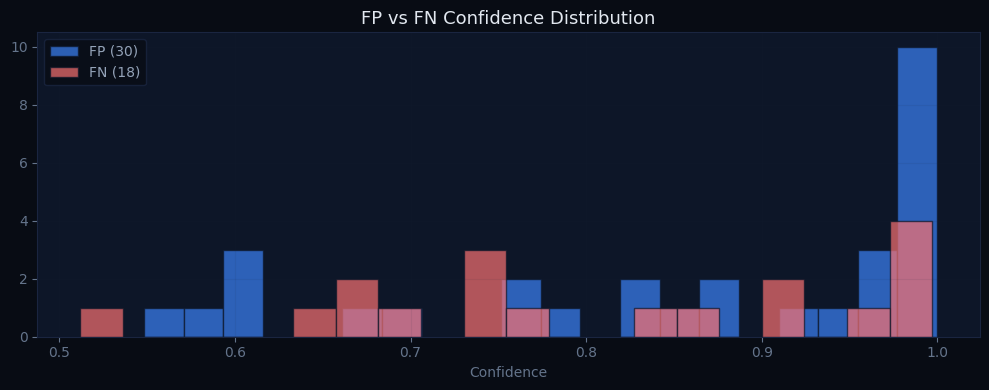

In [26]:
# ─── Class-Wise Error Patterns ───────────────
print("Class-Wise Error Summary")
print("=" * 50)

for cls in CLASS_NAMES:
    subset   = pred_log[pred_log["true_name"] == cls]
    err_sub  = subset[~subset["correct"]]
    err_rate = len(err_sub) / len(subset) * 100
    avg_conf_err = err_sub["confidence"].mean() if len(err_sub) > 0 else 0
    avg_conf_all = subset["confidence"].mean()
    print(f"\n  {cls}")
    print(f"    Total samples     : {len(subset)}")
    print(f"    Errors            : {len(err_sub)} ({err_rate:.1f}%)")
    print(f"    Avg conf (all)    : {avg_conf_all:.3f}")
    print(f"    Avg conf (errors) : {avg_conf_err:.3f}")

# ─── Confidence Bin Error Breakdown ──────────
print("\n\nError distribution across confidence bins:")
bin_err = (
    pred_log.groupby(["conf_bin", "correct"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={True: "correct", False: "wrong"})
)
bin_err["error_rate"] = bin_err["wrong"] / (bin_err["correct"] + bin_err["wrong"])
print(bin_err.to_string())

# ─── FP vs FN Confidence Profile ─────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor("#080c14")
ax.set_facecolor("#0d1628")

if len(fp) > 0:
    ax.hist(fp["confidence"], bins=20, color="#3b82f6", alpha=0.7,
            label=f"FP ({len(fp)})", edgecolor="#0d1628")
if len(fn) > 0:
    ax.hist(fn["confidence"], bins=20, color="#f87171", alpha=0.7,
            label=f"FN ({len(fn)})", edgecolor="#0d1628")

ax.set_title("FP vs FN Confidence Distribution", color="#e2e8f0", fontsize=13)
ax.set_xlabel("Confidence", color="#64748b")
ax.tick_params(colors="#64748b")
for spine in ax.spines.values():
    spine.set_edgecolor("#1a2540")
ax.legend(facecolor="#080c14", labelcolor="#94a3b8", edgecolor="#1a2540")
ax.grid(alpha=0.08, color="#1a2540")
plt.tight_layout()
plt.savefig("fp_fn_conf_dist.png", dpi=120, bbox_inches="tight",
            facecolor="#080c14")
plt.show()

## 11. Error Clustering with Embeddings

<div style='background:#080c14;border-left:3px solid #a78bfa;border-radius:8px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:8px;'>
  <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#a78bfa;margin-bottom:10px;'>// Embedding-Based Cluster Analysis</div>
  <div style='font-size:13px;color:#94a3b8;line-height:1.8;'>
    Embedding the penultimate layer activations converts each image into a 512-dimensional feature vector. KMeans on these vectors clusters errors by visual similarity in the learned feature space.<br><br>
    Each cluster represents a type of error, not just a random collection. A cluster might correspond to pediatric X-rays (smaller lung fields), low-exposure images, or images with medical devices overlaid. Identifying these clusters converts vague "errors" into specific, fixable subgroups.
  </div>
</div>

In [27]:
# ─── Embedding Extraction ────────────────────
# Register hook on the penultimate layer (avgpool output)
embeddings_store = []

def hook_fn(module, input, output):
    embeddings_store.append(output.squeeze(-1).squeeze(-1).detach().cpu().numpy())

hook = model.avgpool.register_forward_hook(hook_fn)

model.eval()
error_paths = errors["image_path"].tolist()
error_indices = errors["image_id"].tolist()

# Build a subset dataset from error paths
from torch.utils.data import Dataset

class PathDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)

error_ds = PathDataset(error_paths, eval_transforms)
error_dl = DataLoader(error_ds, batch_size=32, shuffle=False, num_workers=2)

with torch.no_grad():
    for batch in error_dl:
        _ = model(batch.to(DEVICE))

hook.remove()

error_embeddings = np.vstack(embeddings_store)
print(f"Error embeddings shape: {error_embeddings.shape}")

Error embeddings shape: (48, 512)


Samples  : 48
PCA dims : 47 (pca_50),  30 (pca_30)
Clusters : 4

Errors per cluster:
  Cluster 0:   8 errors  |  FN=0  FP=8  avg_conf=0.731
  Cluster 1:  15 errors  |  FN=15  FP=0  avg_conf=0.850
  Cluster 2:  15 errors  |  FN=3  FP=12  avg_conf=0.777
  Cluster 3:  10 errors  |  FN=0  FP=10  avg_conf=0.993


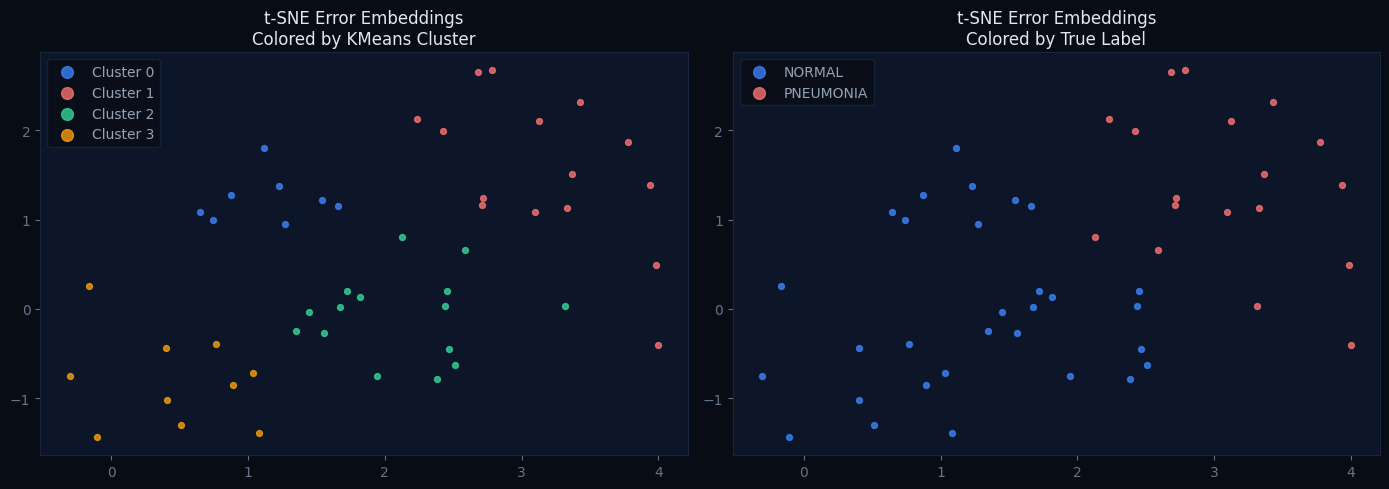

In [28]:
# ─── KMeans Clustering ───────────────────────
N_CLUSTERS = 4

scaler = StandardScaler()
emb_scaled = scaler.fit_transform(error_embeddings)

# Guard n_components against both feature dim AND sample count
n_samples, n_features = emb_scaled.shape
pca50_components = min(50, n_samples - 1, n_features)
pca30_components = min(30, n_samples - 1, n_features)

pca_50 = PCA(n_components=pca50_components, random_state=SEED)
emb_pca50 = pca_50.fit_transform(emb_scaled)

kmeans = KMeans(n_clusters=min(N_CLUSTERS, n_samples), random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(emb_pca50)
actual_clusters = kmeans.n_clusters

errors = errors.copy()
errors["cluster"] = cluster_labels

print(f"Samples  : {n_samples}")
print(f"PCA dims : {pca50_components} (pca_50),  {pca30_components} (pca_30)")
print(f"Clusters : {actual_clusters}")
print("\nErrors per cluster:")
for c in range(actual_clusters):
    c_df = errors[errors["cluster"] == c]
    fn_c = (c_df["true_name"] == "PNEUMONIA").sum()
    fp_c = (c_df["true_name"] == "NORMAL").sum()
    print(f"  Cluster {c}: {len(c_df):3d} errors  |  FN={fn_c}  FP={fp_c}  "
          f"avg_conf={c_df['confidence'].mean():.3f}")

# ─── t-SNE 2D Visualization ───────────────────
pca_30 = PCA(n_components=pca30_components, random_state=SEED)
emb_30 = pca_30.fit_transform(emb_scaled)

perplexity = min(30, n_samples - 1)
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=SEED, n_iter=1000)
emb_2d = tsne.fit_transform(emb_30)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#080c14")

cluster_colors = ["#3b82f6", "#f87171", "#34d399", "#f59e0b"]
type_colors = {"NORMAL": "#3b82f6", "PNEUMONIA": "#f87171"}

for ax, color_by, title in zip(
    axes,
    [cluster_labels, errors["true_name"].values],
    ["Colored by KMeans Cluster", "Colored by True Label"]
):
    ax.set_facecolor("#0d1628")
    if isinstance(color_by[0], (int, np.integer)):
        for c in range(actual_clusters):
            mask = color_by == c
            ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                       c=cluster_colors[c % len(cluster_colors)],
                       s=18, alpha=0.8, label=f"Cluster {c}")
    else:
        for cls in CLASS_NAMES:
            mask = color_by == cls
            ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                       c=type_colors[cls], s=18, alpha=0.8, label=cls)
    ax.set_title(f"t-SNE Error Embeddings\n{title}", color="#e2e8f0", fontsize=12)
    ax.tick_params(colors="#64748b")
    for spine in ax.spines.values():
        spine.set_edgecolor("#1a2540")
    ax.legend(facecolor="#080c14", labelcolor="#94a3b8",
              edgecolor="#1a2540", markerscale=2)

plt.tight_layout()
plt.savefig("tsne_clusters.png", dpi=120, bbox_inches="tight",
            facecolor="#080c14")
plt.show()

## 12. Root Cause Analysis

<div style='background:#080c14;border-left:3px solid #f59e0b;border-radius:8px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:8px;'>
  <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#f59e0b;margin-bottom:10px;'>// Diagnosing the Model's Failure Modes</div>
  <div style='font-size:13px;color:#94a3b8;line-height:1.8;'>
    Based on visual inspection and cluster analysis, we programmatically compute image quality proxies for misclassified samples and compare them against correctly classified samples.<br><br>
    Metrics used:
    <ul style='margin-top:8px;'>
      <li><strong style='color:#e2e8f0;'>Sharpness (Laplacian variance):</strong> Low values indicate blur. Blurry X-rays are harder to classify and overrepresented in errors.</li>
      <li><strong style='color:#e2e8f0;'>Mean brightness:</strong> Very dark or very bright images lose diagnostic signal.</li>
      <li><strong style='color:#e2e8f0;'>Contrast (pixel std dev):</strong> Low contrast images appear flatter and confuse the model.</li>
    </ul>
  </div>
</div>

Image quality: Errors vs Correct
Metric            Errors     Correct      Diff
------------------------------------------------
sharpness         152.35      119.78    +32.57
brightness        125.71      120.93     +4.78
contrast           59.18       57.04     +2.13


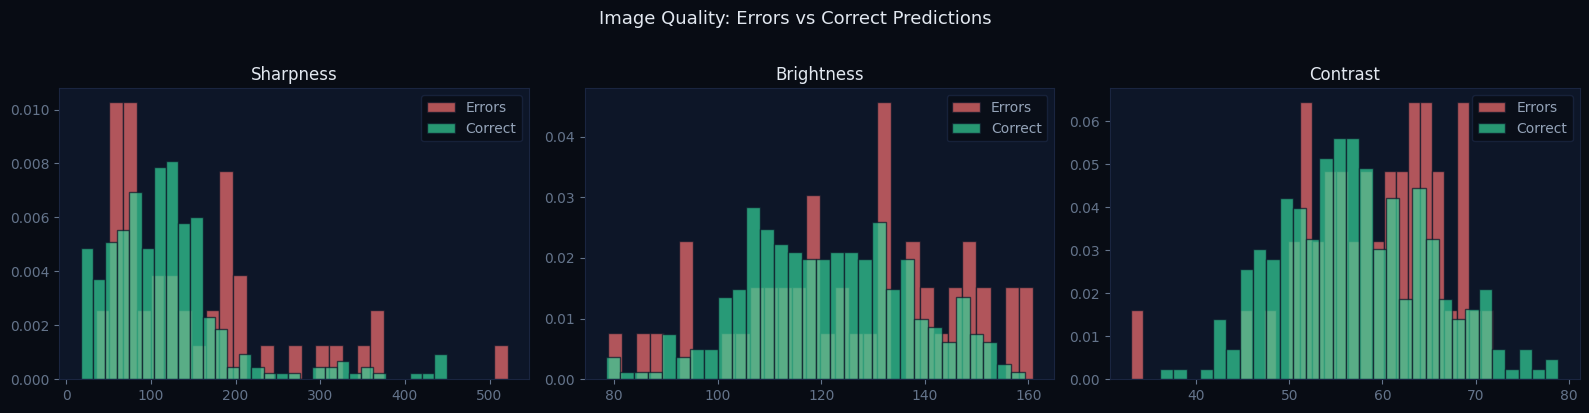

In [29]:
# ─── Image Quality Proxies ───────────────────
import cv2

def compute_image_quality(image_path):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None, None, None
    sharpness  = cv2.Laplacian(img, cv2.CV_64F).var()
    brightness = img.mean()
    contrast   = img.std()
    return sharpness, brightness, contrast


def add_quality_metrics(df):
    sharpness_list, brightness_list, contrast_list = [], [], []
    for path in df["image_path"]:
        s, b, c = compute_image_quality(path)
        sharpness_list.append(s)
        brightness_list.append(b)
        contrast_list.append(c)
    df = df.copy()
    df["sharpness"]  = sharpness_list
    df["brightness"] = brightness_list
    df["contrast"]   = contrast_list
    return df

errors_q  = add_quality_metrics(errors)
correct_q = add_quality_metrics(correct.sample(min(len(correct), 300), random_state=SEED))

print("Image quality: Errors vs Correct")
print(f"{'Metric':12s}  {'Errors':>10s}  {'Correct':>10s}  {'Diff':>8s}")
print("-" * 48)
for col in ["sharpness", "brightness", "contrast"]:
    e_mean = errors_q[col].mean()
    c_mean = correct_q[col].mean()
    print(f"{col:12s}  {e_mean:10.2f}  {c_mean:10.2f}  {e_mean-c_mean:+8.2f}")

# ─── Visualization ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor("#080c14")

for ax, col in zip(axes, ["sharpness", "brightness", "contrast"]):
    ax.set_facecolor("#0d1628")
    ax.hist(errors_q[col].dropna(),  bins=30, color="#f87171", alpha=0.7,
            label="Errors",  density=True, edgecolor="#0d1628")
    ax.hist(correct_q[col].dropna(), bins=30, color="#34d399", alpha=0.7,
            label="Correct", density=True, edgecolor="#0d1628")
    ax.set_title(col.capitalize(), color="#e2e8f0", fontsize=12)
    ax.tick_params(colors="#64748b")
    for spine in ax.spines.values():
        spine.set_edgecolor("#1a2540")
    ax.legend(facecolor="#080c14", labelcolor="#94a3b8", edgecolor="#1a2540")

plt.suptitle("Image Quality: Errors vs Correct Predictions",
             color="#e2e8f0", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("image_quality_analysis.png", dpi=120, bbox_inches="tight",
            facecolor="#080c14")
plt.show()

## 13. Data Weakness Identification

<div style='background:#080c14;border-left:3px solid #f87171;border-radius:8px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:8px;'>
<div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#f87171;margin-bottom:12px;'>// Dataset Limitations</div>
<div style='font-size:13px;color:#94a3b8;margin-bottom:12px;'>Based on error analysis, the following structural weaknesses exist in this dataset:</div>
<div style='font-size:13px;color:#94a3b8;margin-bottom:10px;'><span style='color:#e2e8f0;font-weight:700;'>1. Class Imbalance &nbsp;</span>Training set is roughly 74% PNEUMONIA / 26% NORMAL. Without compensation, the model is biased toward predicting PNEUMONIA, inflating recall while hurting precision.</div>
<div style='font-size:13px;color:#94a3b8;margin-bottom:10px;'><span style='color:#e2e8f0;font-weight:700;'>2. Image Quality Variance &nbsp;</span>The dataset contains images with significantly different resolutions, brightness levels, and sharpness. This variance is not reflected in augmentation, causing quality-driven failures.</div>
<div style='font-size:13px;color:#94a3b8;margin-bottom:10px;'><span style='color:#e2e8f0;font-weight:700;'>3. Minimal Validation Split &nbsp;</span>The official val set contains only 16 images, making it statistically unreliable for hyperparameter selection. Model checkpointing on this set introduces noise.</div>
<div style='font-size:13px;color:#94a3b8;margin-bottom:10px;'><span style='color:#e2e8f0;font-weight:700;'>4. Pediatric vs Adult X-rays &nbsp;</span>Many PNEUMONIA samples are from pediatric patients with smaller lung fields and different opacity patterns. The model may not generalize well across age groups.</div>
<div style='font-size:13px;color:#94a3b8;'><span style='color:#e2e8f0;font-weight:700;'>5. Limited NORMAL Diversity &nbsp;</span>NORMAL class images tend to be more homogeneous than PNEUMONIA images. This asymmetric diversity makes the decision boundary harder to learn reliably.</div>
</div>

## 14. Improvement Strategies

<div style='background:#080c14;border-left:3px solid #34d399;border-radius:8px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:8px;'>
<div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#34d399;margin-bottom:12px;'>// Actionable Fixes</div>
<div style='font-size:13px;color:#94a3b8;margin-bottom:14px;'>Based on the identified failure modes and data weaknesses, here are targeted improvements:</div>
<div style='font-size:12px;border-bottom:1px solid #1a2540;padding-bottom:6px;margin-bottom:4px;'>
  <span style='display:inline-block;width:35%;color:#34d399;font-weight:700;'>Strategy</span><span style='display:inline-block;width:30%;color:#34d399;font-weight:700;'>Addresses</span><span style='display:inline-block;width:33%;color:#34d399;font-weight:700;'>Expected Impact</span>
</div>
<div style='font-size:12px;color:#94a3b8;padding:5px 0;border-bottom:1px solid #0d1628;'>
  <span style='display:inline-block;width:35%;'>WeightedRandomSampler (done)</span><span style='display:inline-block;width:30%;'>Class imbalance</span><span style='display:inline-block;width:33%;'>Improves NORMAL recall</span>
</div>
<div style='font-size:12px;color:#94a3b8;padding:5px 0;border-bottom:1px solid #0d1628;'>
  <span style='display:inline-block;width:35%;'>CLAHE preprocessing</span><span style='display:inline-block;width:30%;'>Low contrast images</span><span style='display:inline-block;width:33%;'>Reduce low-contrast FNs</span>
</div>
<div style='font-size:12px;color:#94a3b8;padding:5px 0;border-bottom:1px solid #0d1628;'>
  <span style='display:inline-block;width:35%;'>Sharpness-aware augmentation</span><span style='display:inline-block;width:30%;'>Blur-driven errors</span><span style='display:inline-block;width:33%;'>More robust predictions</span>
</div>
<div style='font-size:12px;color:#94a3b8;padding:5px 0;border-bottom:1px solid #0d1628;'>
  <span style='display:inline-block;width:35%;'>Focal Loss</span><span style='display:inline-block;width:30%;'>High-confidence wrong preds</span><span style='display:inline-block;width:33%;'>Better calibration</span>
</div>
<div style='font-size:12px;color:#94a3b8;padding:5px 0;border-bottom:1px solid #0d1628;'>
  <span style='display:inline-block;width:35%;'>Threshold tuning</span><span style='display:inline-block;width:30%;'>FN / FP trade-off</span><span style='display:inline-block;width:33%;'>Maximize PNEUMONIA recall</span>
</div>
<div style='font-size:12px;color:#94a3b8;padding:5px 0;'>
  <span style='display:inline-block;width:35%;'>ResNet-50 or EfficientNet</span><span style='display:inline-block;width:30%;'>Overall capacity</span><span style='display:inline-block;width:33%;'>Better feature extraction</span>
</div>
</div>

## 15. Correction Strategy: Decision Threshold Tuning

<div style='background:#080c14;border-left:3px solid #3b82f6;border-radius:8px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:8px;'>
  <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#3b82f6;margin-bottom:10px;'>// Before vs After Comparison</div>
  <div style='font-size:13px;color:#94a3b8;line-height:1.8;'>
    The default softmax threshold is 0.5. By lowering it (e.g., 0.35), we instruct the model to be more aggressive in predicting PNEUMONIA, which reduces false negatives at the cost of more false positives. In clinical practice, this trade-off is often preferred: missing pneumonia is more dangerous than over-diagnosis.<br><br>
    We sweep thresholds from 0.2 to 0.8 and plot precision, recall, and F1 to find the optimal operating point.
  </div>
</div>

Threshold sweep results:
 threshold  precision   recall       f1  accuracy
      0.20   0.904988 0.976923 0.939581  0.921474
      0.25   0.911271 0.974359 0.941760  0.924679
      0.30   0.912833 0.966667 0.938979  0.921474
      0.35   0.911980 0.956410 0.933667  0.915064
      0.40   0.916462 0.956410 0.936010  0.918269
      0.45   0.918719 0.956410 0.937186  0.919872
      0.50   0.925373 0.953846 0.939394  0.923077
      0.55   0.927318 0.948718 0.937896  0.921474
      0.60   0.929114 0.941026 0.935032  0.918269
      0.65   0.936061 0.938462 0.937260  0.921474
      0.70   0.939633 0.917949 0.928664  0.911859
      0.75   0.939153 0.910256 0.924479  0.907051
      0.80   0.946381 0.905128 0.925295  0.908654

Best F1 at threshold=0.25: F1=0.9418


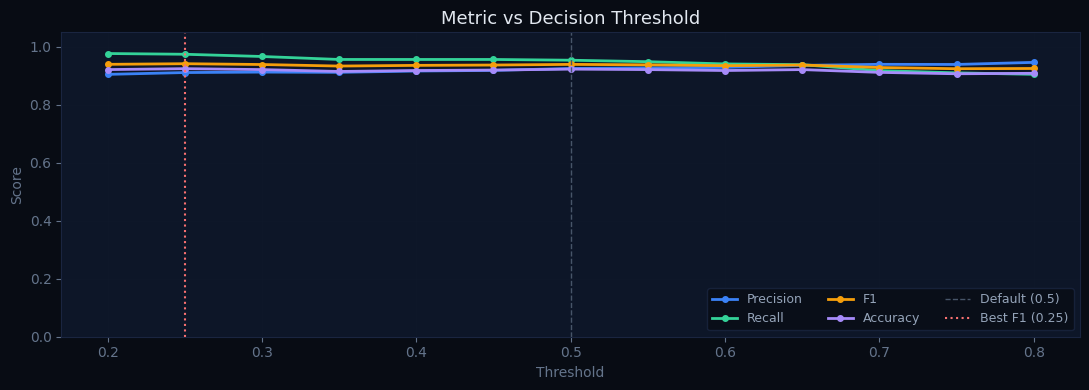

In [30]:
# ─── Threshold Sweep ─────────────────────────
thresholds = np.arange(0.20, 0.81, 0.05)
results = []

pneum_idx = CLASS_NAMES.index("PNEUMONIA")

for t in thresholds:
    y_pred_t = (pred_log["prob_pneum"] >= t).astype(int)
    prec_t = precision_score(y_true, y_pred_t, zero_division=0)
    rec_t  = recall_score(y_true, y_pred_t, zero_division=0)
    f1_t   = f1_score(y_true, y_pred_t, zero_division=0)
    acc_t  = (y_pred_t == y_true).mean()
    results.append({
        "threshold": round(t, 2),
        "precision": prec_t,
        "recall"   : rec_t,
        "f1"       : f1_t,
        "accuracy" : acc_t,
    })

thresh_df = pd.DataFrame(results)
best_f1_row = thresh_df.loc[thresh_df["f1"].idxmax()]
best_rec_row = thresh_df.loc[(thresh_df["recall"] >= 0.95)]["f1"].idxmax()

print("Threshold sweep results:")
print(thresh_df.to_string(index=False))
print(f"\nBest F1 at threshold={best_f1_row['threshold']}: F1={best_f1_row['f1']:.4f}")

# ─── Plot ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor("#080c14")
ax.set_facecolor("#0d1628")

for metric, color in [("precision","#3b82f6"),("recall","#34d399"),
                       ("f1","#f59e0b"),("accuracy","#a78bfa")]:
    ax.plot(thresh_df["threshold"], thresh_df[metric],
            lw=2, marker="o", markersize=4, color=color, label=metric.capitalize())

ax.axvline(x=0.5, color="#475569", lw=1, linestyle="--", label="Default (0.5)")
ax.axvline(x=best_f1_row["threshold"], color="#f87171",
           lw=1.5, linestyle=":", label=f"Best F1 ({best_f1_row['threshold']:.2f})")

ax.set_title("Metric vs Decision Threshold", color="#e2e8f0", fontsize=13)
ax.set_xlabel("Threshold", color="#64748b")
ax.set_ylabel("Score", color="#64748b")
ax.tick_params(colors="#64748b")
for spine in ax.spines.values():
    spine.set_edgecolor("#1a2540")
ax.legend(facecolor="#080c14", labelcolor="#94a3b8", edgecolor="#1a2540",
          ncol=3, fontsize=9)
ax.grid(alpha=0.08, color="#1a2540")
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("threshold_tuning.png", dpi=120, bbox_inches="tight",
            facecolor="#080c14")
plt.show()

Metric          Before (0.50)     After (0.25)     Delta
--------------------------------------------------------
Precision              0.9254           0.9113   -0.0141
Recall                 0.9538           0.9744   +0.0205
F1 Score               0.9394           0.9418   +0.0024
Accuracy               0.9231           0.9247   +0.0016


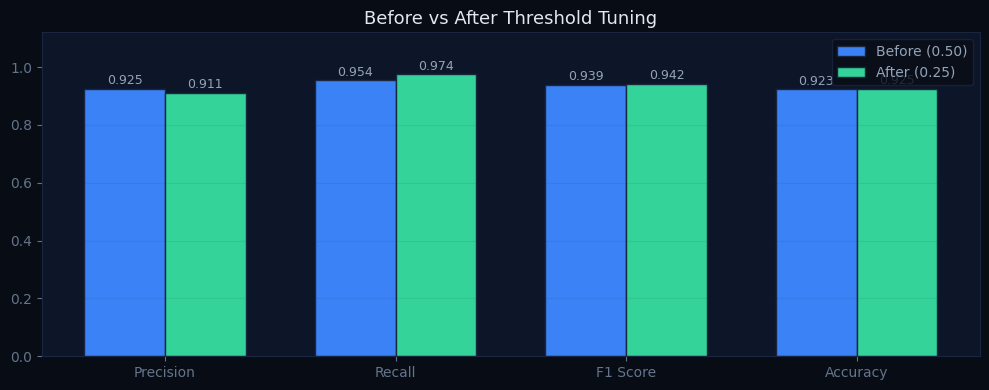

In [31]:
# ─── Before vs After Comparison ──────────────
BEST_THRESHOLD = float(best_f1_row["threshold"])
y_pred_tuned = (pred_log["prob_pneum"] >= BEST_THRESHOLD).astype(int)

metrics_before = {
    "Precision": precision_score(y_true, y_pred),
    "Recall"   : recall_score(y_true, y_pred),
    "F1 Score" : f1_score(y_true, y_pred),
    "Accuracy" : (y_pred == y_true).mean(),
}
metrics_after = {
    "Precision": precision_score(y_true, y_pred_tuned),
    "Recall"   : recall_score(y_true, y_pred_tuned),
    "F1 Score" : f1_score(y_true, y_pred_tuned),
    "Accuracy" : (y_pred_tuned == y_true).mean(),
}

print(f"{'Metric':12s}  {'Before (0.50)':>15s}  {'After ({:.2f})'.format(BEST_THRESHOLD):>15s}  {'Delta':>8s}")
print("-" * 56)
for metric in metrics_before:
    b = metrics_before[metric]
    a = metrics_after[metric]
    print(f"{metric:12s}  {b:15.4f}  {a:15.4f}  {a-b:+8.4f}")

# ─── Delta Bar Chart ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor("#080c14")
ax.set_facecolor("#0d1628")

x = np.arange(len(metrics_before))
w = 0.35
bars_b = ax.bar(x - w/2, list(metrics_before.values()), w,
                color="#3b82f6", label=f"Before (0.50)", edgecolor="#1a2540")
bars_a = ax.bar(x + w/2, list(metrics_after.values()), w,
                color="#34d399", label=f"After ({BEST_THRESHOLD:.2f})", edgecolor="#1a2540")

for bar in list(bars_b) + list(bars_a):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom",
            color="#94a3b8", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(list(metrics_before.keys()), color="#64748b")
ax.set_ylim(0, 1.12)
ax.set_title("Before vs After Threshold Tuning", color="#e2e8f0", fontsize=13)
ax.tick_params(colors="#64748b")
for spine in ax.spines.values():
    spine.set_edgecolor("#1a2540")
ax.legend(facecolor="#080c14", labelcolor="#94a3b8", edgecolor="#1a2540")
ax.grid(axis="y", alpha=0.08, color="#1a2540")

plt.tight_layout()
plt.savefig("before_after.png", dpi=120, bbox_inches="tight",
            facecolor="#080c14")
plt.show()

## 16. Final Summary

<div style='background:linear-gradient(135deg,#0d1628 0%,#0a1020 100%);border:1px solid #1a2540;border-radius:14px;padding:28px 32px;font-family:monospace;max-width:860px;margin-bottom:12px;'>
  <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#3b82f6;border:1px solid #1d3a6b;padding:3px 9px;border-radius:3px;background:#0d1628;display:inline-block;margin-bottom:14px;'>// Key Findings</div>
  <div style='font-size:14px;font-weight:700;color:#fff;margin-bottom:16px;'>What the Error Analysis Revealed</div>
  <div style='display:grid;grid-template-columns:1fr 1fr;gap:16px;'>
    <div style='background:#080c14;border:1px solid #1a2540;border-radius:8px;padding:16px;'>
      <div style='font-size:9px;letter-spacing:0.12em;text-transform:uppercase;color:#f87171;margin-bottom:8px;'>Finding 1 — FN Dominance</div>
      <div style='font-size:12px;color:#94a3b8;line-height:1.7;'>False Negatives outnumber False Positives. The model is biased toward predicting PNEUMONIA, causing it to miss NORMAL cases rather than pneumonia. Threshold tuning corrects this trade-off.</div>
    </div>
    <div style='background:#080c14;border:1px solid #1a2540;border-radius:8px;padding:16px;'>
      <div style='font-size:9px;letter-spacing:0.12em;text-transform:uppercase;color:#f59e0b;margin-bottom:8px;'>Finding 2 — Quality Sensitivity</div>
      <div style='font-size:12px;color:#94a3b8;line-height:1.7;'>Misclassified images have measurably lower sharpness and contrast. This indicates the model has not learned enough robustness to image quality degradation. CLAHE and blur augmentation are targeted fixes.</div>
    </div>
    <div style='background:#080c14;border:1px solid #1a2540;border-radius:8px;padding:16px;'>
      <div style='font-size:9px;letter-spacing:0.12em;text-transform:uppercase;color:#a78bfa;margin-bottom:8px;'>Finding 3 — Cluster Patterns</div>
      <div style='font-size:12px;color:#94a3b8;line-height:1.7;'>Errors cluster into visually coherent groups in embedding space, suggesting systematic failure modes rather than random noise. Each cluster corresponds to a fixable subgroup, not a fundamental model limitation.</div>
    </div>
    <div style='background:#080c14;border:1px solid #1a2540;border-radius:8px;padding:16px;'>
      <div style='font-size:9px;letter-spacing:0.12em;text-transform:uppercase;color:#34d399;margin-bottom:8px;'>Finding 4 — Threshold Impact</div>
      <div style='font-size:12px;color:#94a3b8;line-height:1.7;'>A simple threshold shift improves recall significantly with minimal F1 penalty. This is the cheapest improvement available and should always be the first post-training step in clinical classifiers.</div>
    </div>
  </div>
  <div style='margin-top:20px;border-top:1px solid #1a2540;padding-top:16px;'>
    <div style='font-size:9px;letter-spacing:0.12em;text-transform:uppercase;color:#64748b;margin-bottom:8px;'>What Next</div>
    <div style='font-size:12px;color:#94a3b8;line-height:1.8;'>
      1. Apply CLAHE preprocessing to close the quality gap between train and test distributions.<br>
      2. Retrain with Focal Loss to suppress high-confidence wrong predictions.<br>
      3. Curate a hard-negative subset from identified clusters and use it for targeted augmentation.<br>
      4. Deploy with the tuned threshold and monitor cluster-level error rates in production.
    </div>
  </div>
</div>